In [1]:
#! /usr/bin/env python3
import numpy as np
import sys
import h5py

sys.path.append("../python")  # Adjust the path to build/python/
sys.path.append(".")

## load the necessary modules
from canoe import def_species, load_configure, index_map
from canoe.snap import def_thermo
from canoe.athena import Mesh, ParameterInput, Outputs, MeshBlock
from canoe.harp import radiation_band, radiation

'''
    Overwrite the properties of a specific layer in the meshblock.

    Parameters:
    mb (MeshBlock): The meshblock containing the air column.
    ilayer (int): The index of the layer to overwrite.
    temp (float): K
    nh3_ppmv (float): The NH3 mixing ratio in ppmv to set for the layer.
    h2o_ppmv (float): The H2O mixing ratio in ppmv to set for the layer.
    electron (float): The electron density to set for the layer.
'''


def query_layer_properties(mb, ilayer):
    """
    Check if the layer has the required properties.
    If not, raise an error.
    """
    aircolumn = mb.get_aircolumn(mb.k_st, mb.j_st + Jindex, mb.i_st, mb.i_ed)  
    ap_mole = aircolumn[ilayer].to_mole_fraction()

    P = ap_mole.get_pressure()
    T = ap_mole.get_temp()
    theta = mb.get_theta(P0, mb.k_st, mb.j_st + Jindex, mb.i_st + ilayer)
    # print(f"  Θ = {theta:0.2f} K")
    xnh3=ap_mole.hydro()[iNH3] * 1E6
    xH2O = ap_mole.hydro()[iH2O] * 1E6
    
    elec=mb.get_tracer(ielec, mb.k_st, mb.j_st + Jindex, mb.i_st + ilayer) 
    # Na=mb.get_tracer(iNa, mb.k_st, mb.j_st + Jindex, mb.i_st + ilayer)  
    print(f"Layer {ilayer}: P={P:0.2f} Pa, T={T:0.2f} K, NH3={xnh3:0.2f} ppmv, H2O={xH2O:0.2f} ppmv, e-={elec:0.2E} m^-3")
    return P, T, xnh3, xH2O, elec

def overwrite_layer_properties(mb, ilayer, temp, nh3_ppmv, h2o_ppmv, electron):

    aircolumn = mb.get_aircolumn(mb.k_st, mb.j_st + Jindex, mb.i_st, mb.i_ed)  
    ap_mole = aircolumn[ilayer].to_mole_fraction()

    # set temperature, NH3, H2O
    ap_mole.set_temp(temp)
    ap_mole.set_property(iNH3, nh3_ppmv/1E6)
    ap_mole.set_property(iH2O, h2o_ppmv/1E6)

    # put back to the air column
    mb.distribute_to_primitive(mb.k_st, mb.j_st + Jindex, mb.i_st + ilayer, ap_mole)

    # set electron
    mb.set_tracer_layer(ielec, mb.j_st +Jindex, mb.i_st + ilayer, electron)  
    # mb.set_tracer_layer(iNa, mb.j_st +Jindex, mb.i_st + ilayer, 0.0) 


In [ ]:

## ========================================================================
##                       configure the Juno MWR forward model
##--------------------------------------------------------------------------
# load the configuration file
pin = ParameterInput()
pin.load_from_file("juno_mwr.inp")
pin.set_boolean("job", "verbose", False)  

# register the speicies and thermodynamics
vapors = pin.get_string("species", "vapor").split(", ")
clouds = pin.get_string("species", "cloud").split(", ")
tracers = pin.get_string("species", "tracer").split(", ")

def_species(vapors=vapors, clouds=clouds, tracers=tracers)
def_thermo(pin)

# load bands and opacities
config = load_configure("juno_mwr.yaml")


# set incident angles 
angle =[0.0, 15, 30.0, 45.]  # in degrees
angles = ' '.join([f"({x},)" for x in angle])
pin.set_string("radiation","outdir",angles)
print(pin.get_string("radiation","outdir"))


# set the gravity 
pin.set_string("hydro", "grav_acc1", f"{-23.3}") # Equatorial zone
# pin.set_string("hydro", "grav_acc1", f"{-27.01}") # pole 
print("Gravity acceleration:", pin.get_string("hydro", "grav_acc1"))


# get index_map 
pindex = index_map.get_instance()
iNH3 = pindex.get_vapor_id("NH3")
iH2O = pindex.get_vapor_id("H2O")
ielec = pindex.get_tracer_id("e-")  # index for electron
iNa = pindex.get_tracer_id("Na")  # index for sodium

print(f"iNH3 = {iNH3}, iH2O = {iH2O}, ielec = {ielec}, iNa = {iNa}")

P0 = pin.get_real("mesh", "ReferencePressure")
print(f"Reference Pressure: {P0} Pa")


# set mesh; we use the 1st column of the 1st meshblock of the Athena++ mesh
nx2 = 1  # air column number, single column in this case
pin.set_string("mesh", "nx2", f"{nx2}")

# init the Mesh
mesh = Mesh(pin) 
mesh.initialize(pin)

global mb
# get the first meshblock
mb = mesh.meshblock(0)  


##=============================================================================================
##                  construct atmosphere: moist adiabate + constant NH3
##---------------------------------------------------------------------------------------------

# EZ abundances and temperature in Cheng (2020) 
xNH3=351     # deep-layer abundance, ppmv
xH2O=2500    # ppmv
T1bar=169    # 1-bar temperature, K

## use the first ap column of the block
Jindex=0   # Jindex ∈ [0, nx2-1]

## RH limit 
RHmax=1  # limit of relative humidity, 1 means 100%, only affects NH3 cloud-layer, set to 1 in EZ
maxint=200  # do not change

## a moist adiabatic uniform NH3 profile, with RHlimit
adiabate="pseudo"  # or "dry"

# construct the atmosphere
mb.construct_atmosphere(pin, xNH3, T1bar, RHmax, Jindex, adiabate, xH2O, maxint)

# ----------------------------  get the pressure grid  -----------------------------------------
aircolumn = mb.get_aircolumn(mb.k_st, mb.j_st + Jindex, mb.i_st, mb.i_ed)   
#### loop over layers bottom up
pressure= np.array([0.0] * len(aircolumn))  # pressure in Pa

# get T, P, and θ for each layer
for i in range(len(aircolumn)): 
    pressure[i] = aircolumn[i].get_pressure()  # pressure in Pa

print(f"Pressure grid: {pressure}")

## ===============================================================================================
##                          modify the profile
## -----------------------------------------------------------------------------------------------

# assuming we want to modify the 

# pas=[7000E5, 1000E5, 500E5, 100E5, 10E5]  # pressure in Pa
# xNH3 = np.array([110.0, 150.0, 200.0, 300.0, 400.0][::-1]) # NH3 mixing ratio in ppmv
# xH2O = np.array([100.0, 1000.0, 2000.0, 3000.0, 4000.0][::-1])  # H2O mixing ratio in ppmv
# temps = np.array([2000, 1500, 1000, 500, 300]) # temperature in K
# # electron density in m^-3
# electron = np.array([1E16, 1E15, 1E14, 1E13, 1E12])    # electron number density in m^-3

# for irec, rec in enumerate(zip(pas, xNH3, xH2O, temps, electron)):
#     pa, nh3_ppmv, h2o_ppmv, temp, elec = rec
#     # find the layer index for the given pressure
    # ilayer = np.argmin(np.abs(pressure - pa))

    # query_layer_properties(mb, ilayer)

    # # overwrite the layer properties
    # overwrite_layer_properties(mb, ilayer, temp, nh3_ppmv, h2o_ppmv, elec)

    # # check the layer properties after modification
    # query_layer_properties(mb, ilayer)


for ilayer in range(len(aircolumn)):
    # query the layer properties
    P, T, xnh3, xH2O, elec = query_layer_properties(mb, ilayer)

    electron = elec *10  # example electron density in m^-3

    overwrite_layer_properties(mb, ilayer, T, xnh3, xH2O, electron)

    # check the layer properties after modification
    query_layer_properties(mb, ilayer)




## ===============================================================================================
##                              calculate the profile  
## -----------------------------------------------------------------------------------------------

#### loop over layers bottom up
nlyr=len(aircolumn)             ## default 1600 pressure layers

SH_NH3= np.array([0.0]*nlyr)    ## specific mixing ratio, kg/kg
RH_NH3= np.array([0.0]*nlyr)    ## relative humidity
# SH_H2O= np.array([0.0]*nlyr)    ## specific mixing ratio, kg/kg
# RH_H2O= np.array([0.0]*nlyr)    ## relative humidity

NH3_ppmv= np.array([0.0]*nlyr)   ## mole fraction, eg., 380 ppmv
# H2O_ppmv= np.array([0.0]*nlyr)   ## mole fraction, eg., 2500 ppmv

temp= np.array([0.0]*nlyr)      ## temperature, K
theta= np.array([0.0]*nlyr)     ## potential temperature, K, reference pressure P0 = 1 bar

Es= np.array([0.0]*nlyr)      ## temperature, K
Nas= np.array([0.0]*nlyr)     ## potential temperature, K, reference pressure P0 = 1 bar


for i in range(nlyr): 
    ap = aircolumn[i]
    SH_NH3[i] = ap.hydro()[iNH3]
    # SH_H2O[i] = ap.hydro()[iH2O]
    
    ap_mole = ap.to_mole_fraction()
    RH_NH3[i] = ap_mole.get_rh(iNH3)
    # RH_H2O[i] = ap_mole.get_rh(iH2O)

    NH3_ppmv[i] = ap_mole.hydro()[iNH3]*1E6  
    # H2O_ppmv[i] = ap_mole.hydro()[iH2O]*1E6  

    ## temp and theta should be calculated before applying NH3 gradient, or it will be wrong.
    temp[i] = mb.get_temp(mb.k_st, mb.j_st + Jindex,mb.i_st + i)    
    theta[i] = mb.get_theta(P0, mb.k_st, mb.j_st + Jindex,mb.i_st + i)

    Es[i]=mb.get_tracer(ielec, mb.k_st, mb.j_st + Jindex, mb.i_st + i)  # get the electron tracer for this layer
    Nas[i]=mb.get_tracer(iNa, mb.k_st, mb.j_st + Jindex, mb.i_st + i)  # get the sodium tracer for this layer
    
# # Save the results to an HDF5 file
# with h5py.File('juno_mwr_fwd_case-EZ-overwritten_profiles.h5', 'w') as h5file:
#     h5file.create_dataset('SH_NH3', data=SH_NH3)
#     h5file.create_dataset('RH_NH3', data=RH_NH3)
#     h5file.create_dataset('NH3_ppmv', data=NH3_ppmv)
#     h5file.create_dataset('temp', data=temp)
#     h5file.create_dataset('theta', data=theta)
#     h5file.create_dataset('Es', data=Es)
#     h5file.create_dataset('Nas', data=Nas)




## ===============================================================================================
##                           calculate the radiance
## -----------------------------------------------------------------------------------------------

# get radance obj
rad = mb.get_rad()
nband = rad.get_num_bands()

# calculate the radiance for the Jindex_st column
rad.cal_radiance(mb, mb.k_st, mb.j_st + Jindex)
nray=len(angle)
tb = np.zeros(( nband,nray), dtype=np.float64)  # radiance in W/m^2/sr/cm^-1

print(f"Number of bands: {nband}, Number of angles: {nray}")

for ib in range(nband):
    toa = rad.get_band(ib).get_toa()[0]
    tb[ ib,:] = toa

print(tb)

with h5py.File('run_juno_forward_overwrite_radiance-test2.h5', 'w') as h5file:
    h5file.create_dataset('tb', data=tb)
    h5file.create_dataset('angle', data=angle)


# ## -------------   use-inbuilt default output for more variables   ------------------

# print(pin.set_string("job", "problem_id","juno_mwr_fwd_overwritten_profiles"))
# out = Outputs(mesh, pin)
# out.make_outputs(mesh, pin)
# import os
# os.system("./combine.py")

# ## ---------------------------------------------------------------

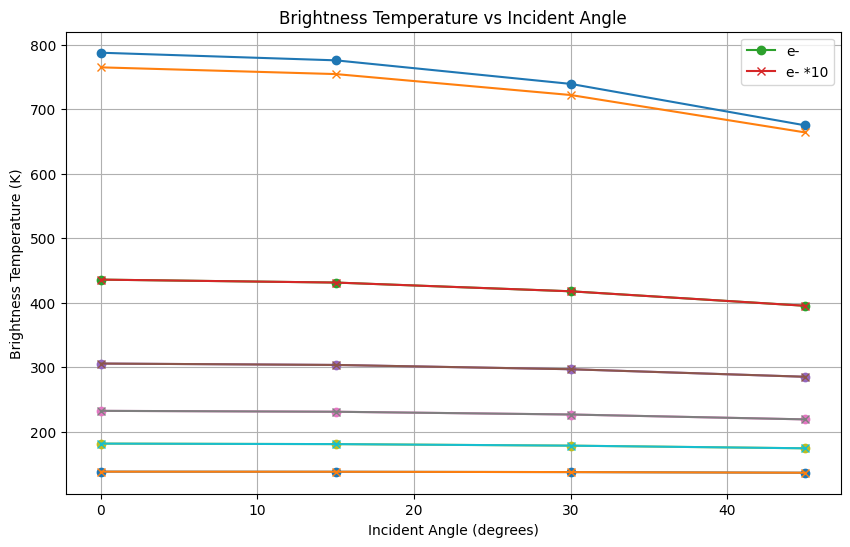

In [3]:
with h5py.File('run_juno_forward_overwrite_radiance-test1.h5', 'r') as h5file:
    tb1 = h5file['tb'][:]
    angle = h5file['angle'][:]

with h5py.File('run_juno_forward_overwrite_radiance-test2.h5', 'r') as h5file:
    tb2 = h5file['tb'][:]
    angle = h5file['angle'][:]

# plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
for ib in range(nband):
    # plt.plot(angle, tb1[ib]-tb2[ib], label=f'channel {ib+1}', marker='o')
    plt.plot(angle, tb1[ib], marker='o')
    plt.plot(angle, tb2[ib], marker='x')

plt.plot([],[], marker='o', label="e-")
plt.plot([],[], marker='x', label="e- *10")

plt.xlabel('Incident Angle (degrees)')
plt.ylabel('Brightness Temperature (K)')
plt.title('Brightness Temperature vs Incident Angle')
# plt.ylim(700,800)
plt.legend()
plt.grid()
